# GRPO와 다음 단계

> DPO가 "사람의 선호"를 학습한다면, GRPO는 "객관적 정답"으로 스스로 학습한다

DPO는 주관적 선호도(더 친절한 답변)에 적합하지만,  
수학/코드처럼 **객관적 정답이 있는 태스크**에서는 GRPO가 더 효율적이다.  
이 노트북에서 GRPO 원리를 이해하고, 정렬 기법 전체를 조망한다.

In [ ]:
# === 환경 설치 ===
!pip install matplotlib numpy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("Phase 6-04: GRPO와 다음 단계")

Phase 6-04: GRPO와 다음 단계


---
## 1. DPO의 한계

| 상황 | DPO | GRPO |
|------|-----|------|
| "더 친절한 답변은?" | 적합 (주관적 선호) | 부적합 |
| "2+3의 정답은?" | 비효율 (preference 쌍 필요) | 적합 (정답 여부로 자동 보상) |
| "이 코드가 맞는가?" | 비효율 | 적합 (실행 결과로 검증) |

DPO는 **사람이 라벨링한 preference 쌍**이 필요하다.  
수학/코드처럼 객관적 정답이 있는 태스크에서는 GRPO가 더 효율적이다.

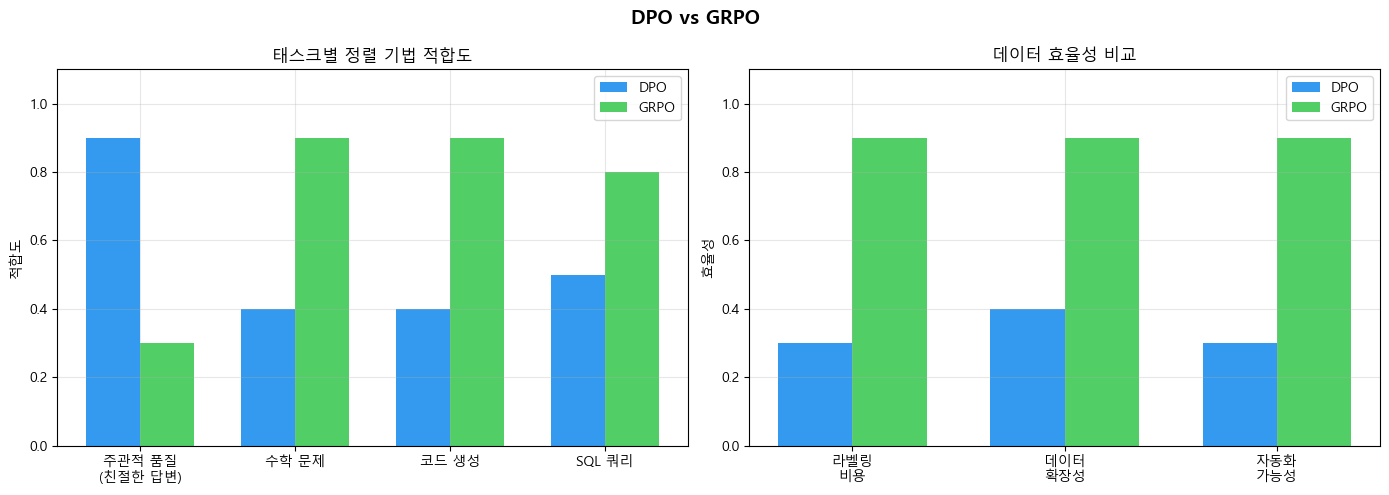

In [2]:
# === DPO vs GRPO 비교 시각화 ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 태스크별 적합도
tasks = ['주관적 품질\n(친절한 답변)', '수학 문제', '코드 생성', 'SQL 쿼리']
dpo_scores = [0.9, 0.4, 0.4, 0.5]
grpo_scores = [0.3, 0.9, 0.9, 0.8]

x = np.arange(len(tasks))
width = 0.35
axes[0].bar(x - width/2, dpo_scores, width, label='DPO', color='#339af0')
axes[0].bar(x + width/2, grpo_scores, width, label='GRPO', color='#51cf66')
axes[0].set_ylabel('적합도')
axes[0].set_title('태스크별 정렬 기법 적합도')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tasks)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3)

# 2) 데이터 요구사항
categories = ['라벨링\n비용', '데이터\n확장성', '자동화\n가능성']
dpo_data = [0.3, 0.4, 0.3]  # 높을수록 좋음
grpo_data = [0.9, 0.9, 0.9]

x2 = np.arange(len(categories))
axes[1].bar(x2 - width/2, dpo_data, width, label='DPO', color='#339af0')
axes[1].bar(x2 + width/2, grpo_data, width, label='GRPO', color='#51cf66')
axes[1].set_ylabel('효율성')
axes[1].set_title('데이터 효율성 비교')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(categories)
axes[1].legend()
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3)

plt.suptitle('DPO vs GRPO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. GRPO 원리

DeepSeek R1에서 사용된 기법. **보상 모델 없이 규칙 기반 보상**으로 학습한다.

```
1. 질문 Q에 대해 모델이 N개 응답 샘플링 (o1, o2, ..., oN)
2. 각 응답에 규칙 기반 보상 부여 (r1, r2, ..., rN)
3. 그룹 평균으로 baseline 계산: b = mean(r1...rN)
4. 각 응답의 advantage: Ai = ri - b
5. advantage가 높은 응답의 확률을 높이도록 학습
```

In [3]:
# === GRPO 시뮬레이션 ===

print("GRPO 시뮬레이션: '2 + 3 = ?' 문제")
print("=" * 50)

# 모델이 4개 응답 생성
responses = [
    {"text": "5", "correct": True, "has_reasoning": False},
    {"text": "6", "correct": False, "has_reasoning": False},
    {"text": "2+3=5, 따라서 답은 5입니다", "correct": True, "has_reasoning": True},
    {"text": "모르겠습니다", "correct": False, "has_reasoning": False},
]

# 규칙 기반 보상 함수
def math_reward(response):
    reward = 0.0
    if response["correct"]:
        reward += 1.0
    if response["has_reasoning"]:
        reward += 0.1  # 풀이 과정 보너스
    return reward

rewards = [math_reward(r) for r in responses]
baseline = np.mean(rewards)
advantages = [r - baseline for r in rewards]

print(f"\n{'응답':<35} {'보상':>6} {'baseline':>10} {'advantage':>10}")
print("-" * 65)
for i, (resp, reward, adv) in enumerate(zip(responses, rewards, advantages)):
    marker = "↑" if adv > 0 else "↓" if adv < 0 else "="
    print(f"  {resp['text']:<33} {reward:>6.1f} {baseline:>10.3f} {adv:>9.3f} {marker}")

print(f"\nbaseline = mean({rewards}) = {baseline:.3f}")
print(f"\n→ advantage > 0인 응답(1, 3)의 생성 확률 ↑")
print(f"→ advantage < 0인 응답(2, 4)의 생성 확률 ↓")

GRPO 시뮬레이션: '2 + 3 = ?' 문제

응답                                      보상   baseline  advantage
-----------------------------------------------------------------
  5                                    1.0      0.525     0.475 ↑
  6                                    0.0      0.525    -0.525 ↓
  2+3=5, 따라서 답은 5입니다                   1.1      0.525     0.575 ↑
  모르겠습니다                               0.0      0.525    -0.525 ↓

baseline = mean([1.0, 0.0, 1.1, 0.0]) = 0.525

→ advantage > 0인 응답(1, 3)의 생성 확률 ↑
→ advantage < 0인 응답(2, 4)의 생성 확률 ↓


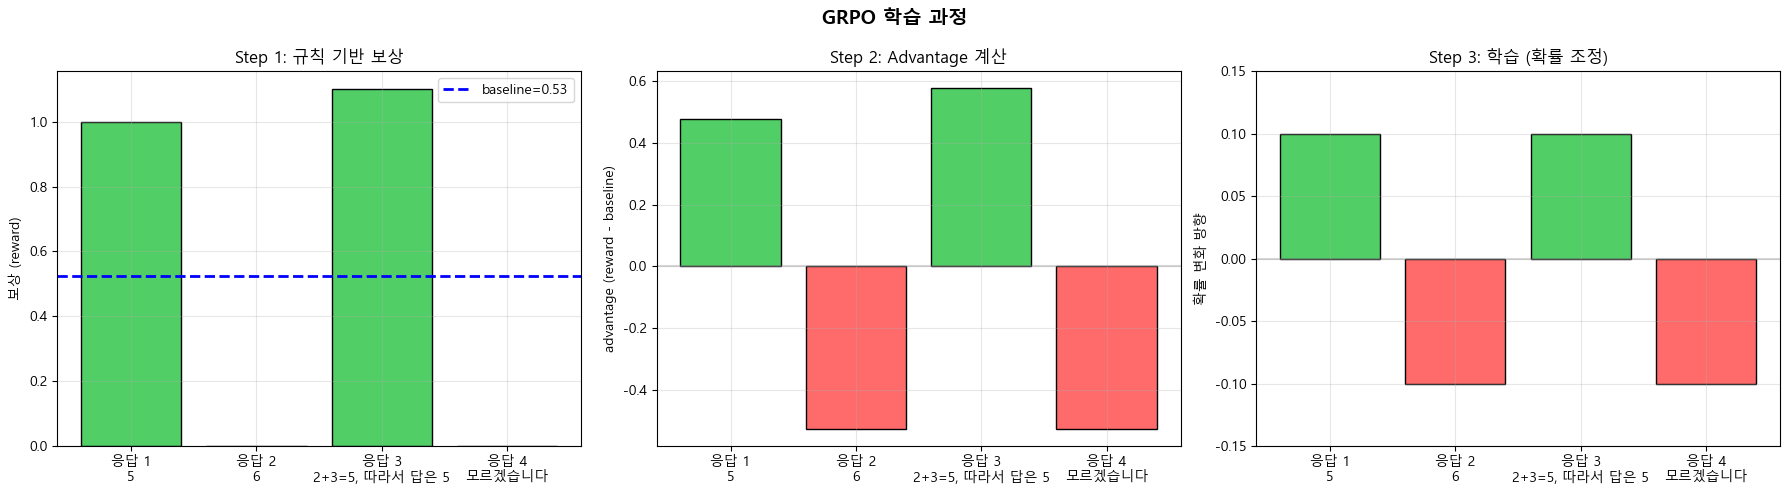

In [4]:
# === GRPO Advantage 시각화 ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 보상 분포
labels = [f"응답 {i+1}\n{r['text'][:15]}" for i, r in enumerate(responses)]
colors = ['#51cf66' if a > 0 else '#ff6b6b' for a in advantages]
axes[0].bar(labels, rewards, color=colors, edgecolor='black')
axes[0].axhline(y=baseline, color='blue', linestyle='--', linewidth=2, label=f'baseline={baseline:.2f}')
axes[0].set_ylabel('보상 (reward)')
axes[0].set_title('Step 1: 규칙 기반 보상')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2) Advantage
axes[1].bar(labels, advantages, color=colors, edgecolor='black')
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[1].set_ylabel('advantage (reward - baseline)')
axes[1].set_title('Step 2: Advantage 계산')
axes[1].grid(True, alpha=0.3)

# 3) 확률 업데이트 방향
prob_changes = [0.1 if a > 0 else -0.1 if a < 0 else 0 for a in advantages]
axes[2].bar(labels, prob_changes, color=colors, edgecolor='black')
axes[2].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[2].set_ylabel('확률 변화 방향')
axes[2].set_title('Step 3: 학습 (확률 조정)')
axes[2].set_ylim(-0.15, 0.15)
axes[2].grid(True, alpha=0.3)

plt.suptitle('GRPO 학습 과정', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. 보상 함수 설계

GRPO의 핵심은 **태스크에 맞는 보상 함수를 직접 설계**하는 것이다.

| 태스크 | 보상 기준 | 점수 |
|--------|----------|------|
| 수학 | 정답 여부 + 풀이 과정 | 1.0 + 0.1 |
| 코드 | 실행 성공 + 테스트 통과 수 | 0~1.0 |
| SQL | 실행 결과 일치 여부 | 0 or 1.0 |

In [5]:
# === 다양한 보상 함수 예시 ===

def math_reward_function(response_text, correct_answer):
    """수학 문제 보상 함수"""
    reward = 0.0
    # 정답 체크
    if str(correct_answer) in response_text:
        reward += 1.0
    # 풀이 과정 체크
    reasoning_keywords = ['따라서', 'because', '=', '계산']
    if any(kw in response_text.lower() for kw in reasoning_keywords):
        reward += 0.1
    return reward

def code_reward_function(code_text, test_cases):
    """코드 생성 보상 함수 (개념)"""
    reward = 0.0
    # 문법 체크
    try:
        compile(code_text, '<string>', 'exec')
        reward += 0.3  # 컴파일 성공
    except SyntaxError:
        return 0.0
    # 테스트 통과율 (개념적)
    # passed = sum(run_test(code_text, tc) for tc in test_cases)
    # reward += 0.7 * (passed / len(test_cases))
    return reward

def sql_reward_function(sql_text, expected_result):
    """SQL 보상 함수 (개념)"""
    reward = 0.0
    # SQL 문법 키워드 체크
    sql_keywords = ['SELECT', 'FROM']
    if all(kw in sql_text.upper() for kw in sql_keywords):
        reward += 0.3
    # 실행 결과 일치 (개념적)
    # actual = execute_sql(sql_text)
    # if actual == expected_result:
    #     reward += 0.7
    return reward

# 테스트
print("보상 함수 테스트:")
print(f"  math_reward('2+3=5, 따라서 답은 5', 5) = {math_reward_function('2+3=5, 따라서 답은 5', 5)}")
print(f"  math_reward('6', 5) = {math_reward_function('6', 5)}")
print(f"  code_reward('def f(): return 1', []) = {code_reward_function('def f(): return 1', [])}")
print(f"  code_reward('def f( return', []) = {code_reward_function('def f( return', [])}")
print(f"  sql_reward('SELECT * FROM users', '') = {sql_reward_function('SELECT * FROM users', '')}")

보상 함수 테스트:
  math_reward('2+3=5, 따라서 답은 5', 5) = 1.1
  math_reward('6', 5) = 0.0
  code_reward('def f(): return 1', []) = 0.3
  code_reward('def f( return', []) = 0.0
  sql_reward('SELECT * FROM users', '') = 0.3


---
## 4. GRPO 학습 시뮬레이션

여러 에폭에 걸쳐 GRPO가 어떻게 모델을 개선하는지 시뮬레이션한다.

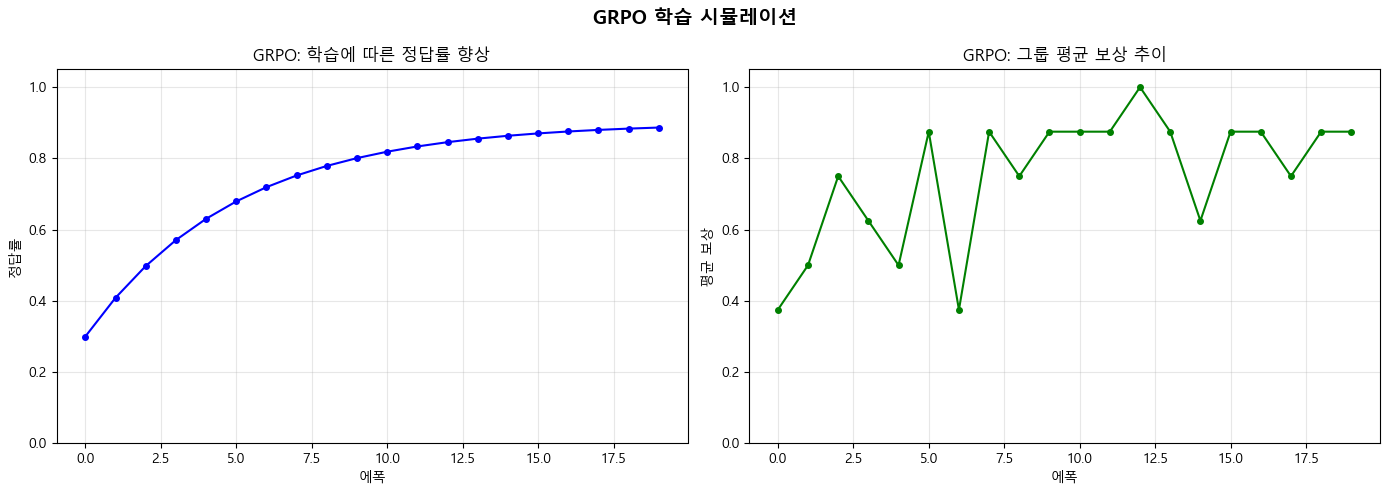

정답률: 0.30 → 0.89
평균 보상: 0.38 → 0.88


In [6]:
# === GRPO 학습 과정 시뮬레이션 ===

np.random.seed(42)

# 시뮬레이션: 정답률이 학습에 따라 향상
epochs = 20
n_samples = 8  # 질문당 샘플 수

accuracy_history = []
avg_reward_history = []
initial_accuracy = 0.3  # 초기 정답률

for epoch in range(epochs):
    # 학습에 따라 정답률 향상 (시뮬레이션)
    current_accuracy = initial_accuracy + (0.9 - initial_accuracy) * (1 - np.exp(-0.2 * epoch))
    
    # N개 샘플 생성
    is_correct = np.random.random(n_samples) < current_accuracy
    rewards = is_correct.astype(float)
    
    # GRPO advantage
    baseline = rewards.mean()
    advantages = rewards - baseline
    
    accuracy_history.append(current_accuracy)
    avg_reward_history.append(baseline)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 정답률 향상
axes[0].plot(range(epochs), accuracy_history, 'b-o', markersize=4)
axes[0].set_xlabel('에폭')
axes[0].set_ylabel('정답률')
axes[0].set_title('GRPO: 학습에 따른 정답률 향상')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# 2) 평균 보상
axes[1].plot(range(epochs), avg_reward_history, 'g-o', markersize=4)
axes[1].set_xlabel('에폭')
axes[1].set_ylabel('평균 보상')
axes[1].set_title('GRPO: 그룹 평균 보상 추이')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.suptitle('GRPO 학습 시뮬레이션', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"정답률: {accuracy_history[0]:.2f} → {accuracy_history[-1]:.2f}")
print(f"평균 보상: {avg_reward_history[0]:.2f} → {avg_reward_history[-1]:.2f}")

---
## 5. GRPOTrainer 코드 스케치

TRL의 `GRPOTrainer`를 사용한 실전 코드 구조.  
**참고용** — 전체 실행은 VRAM이 많이 필요하므로 코드 구조만 확인한다.

In [7]:
# === GRPOTrainer 코드 스케치 (참고용, 실행하지 않음) ===

grpo_code = '''
from trl import GRPOConfig, GRPOTrainer

# 보상 함수 정의
def reward_fn(completions, prompts=None, **kwargs):
    """규칙 기반 보상 함수"""
    rewards = []
    for completion in completions:
        text = completion  # 모델 생성 텍스트
        # 태스크에 맞는 보상 로직
        reward = math_reward_function(text, correct_answer)
        rewards.append(reward)
    return rewards

# GRPO 설정
grpo_config = GRPOConfig(
    output_dir="./output/grpo_run",
    num_generations=4,          # 질문당 생성할 응답 수 (N)
    learning_rate=5e-6,         # DPO보다도 보수적
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    bf16=True,
    max_completion_length=256,
    report_to="none",
)

# GRPO Trainer
grpo_trainer = GRPOTrainer(
    model=peft_model,
    processing_class=tokenizer,
    reward_funcs=[reward_fn],   # 보상 함수 리스트
    train_dataset=train_data,   # prompt만 있으면 됨
    args=grpo_config,
)

grpo_trainer.train()
'''

print("GRPOTrainer 코드 구조:")
print(grpo_code)
print("핵심 차이점:")
print("  1. reward_funcs: 보상 함수를 직접 전달 (DPO에는 없음)")
print("  2. num_generations: 질문당 N개 응답 생성 (GRPO의 'G')")
print("  3. chosen/rejected 데이터 불필요 → prompt + 정답만 있으면 됨")

GRPOTrainer 코드 구조:

from trl import GRPOConfig, GRPOTrainer

# 보상 함수 정의
def reward_fn(completions, prompts=None, **kwargs):
    """규칙 기반 보상 함수"""
    rewards = []
    for completion in completions:
        text = completion  # 모델 생성 텍스트
        # 태스크에 맞는 보상 로직
        reward = math_reward_function(text, correct_answer)
        rewards.append(reward)
    return rewards

# GRPO 설정
grpo_config = GRPOConfig(
    output_dir="./output/grpo_run",
    num_generations=4,          # 질문당 생성할 응답 수 (N)
    learning_rate=5e-6,         # DPO보다도 보수적
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    bf16=True,
    max_completion_length=256,
    report_to="none",
)

# GRPO Trainer
grpo_trainer = GRPOTrainer(
    model=peft_model,
    processing_class=tokenizer,
    reward_funcs=[reward_fn],   # 보상 함수 리스트
    train_dataset=train_data,   # prompt만 있으면 됨
    args=grpo_config,
)

grpo_trainer.train()

핵심 차이점:
  1. reward_funcs: 보상 함수를 직접 전달 (DPO에는 없음)
  2. nu

---
## 6. 정렬 기법 종합 비교

| 기법 | 보상 신호 | 필요 데이터 | 구현 난이도 | 적합한 태스크 |
|------|----------|-----------|-----------|------------|
| RLHF (PPO) | 학습된 Reward Model | Preference 쌍 | 매우 높음 | 범용 정렬 |
| **DPO** | **Implicit** | **Preference 쌍** | **낮음** | **범용 정렬** |
| **GRPO** | **규칙 기반 보상** | **문제 + 정답** | **중간** | **수학/코드/추론** |
| KTO | Binary (좋음/나쁨) | 단일 응답 + 라벨 | 낮음 | 데이터 적을 때 |
| ORPO | SFT+DPO 통합 | Preference 쌍 | 낮음 | 효율적 학습 |

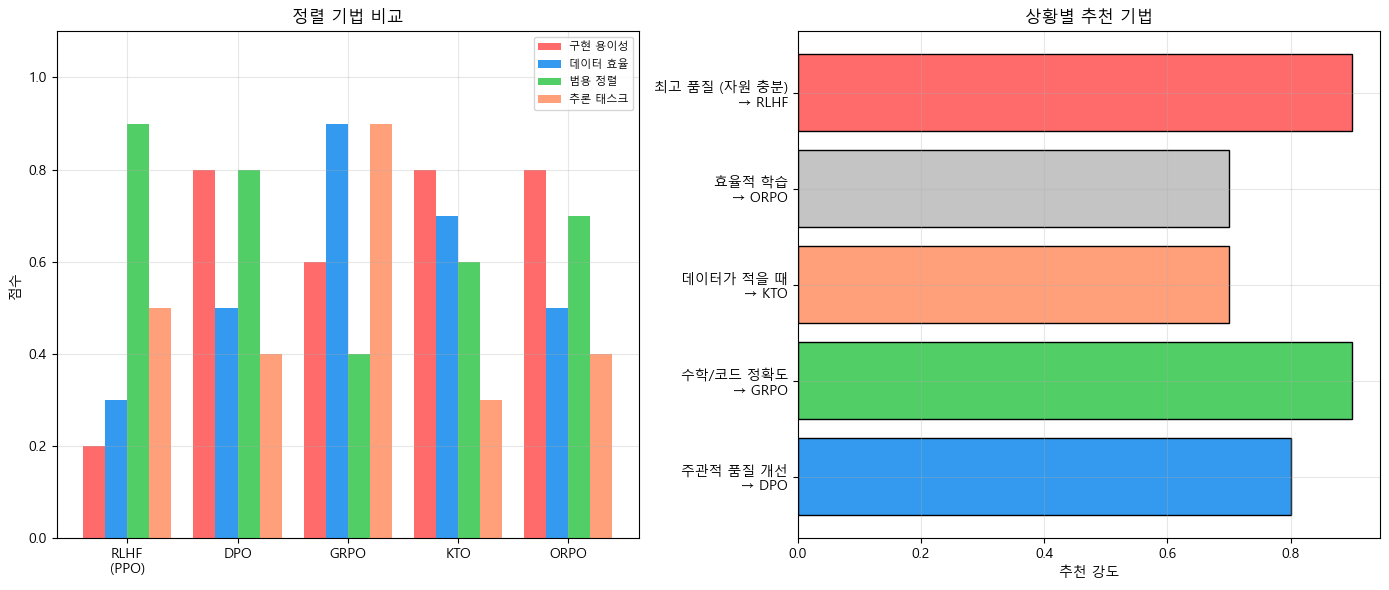

In [8]:
# === 정렬 기법 종합 비교 시각화 ===

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1) 레이더 차트 (막대로 대체)
methods = ['RLHF\n(PPO)', 'DPO', 'GRPO', 'KTO', 'ORPO']
metrics = {
    '구현 용이성': [0.2, 0.8, 0.6, 0.8, 0.8],
    '데이터 효율': [0.3, 0.5, 0.9, 0.7, 0.5],
    '범용 정렬': [0.9, 0.8, 0.4, 0.6, 0.7],
    '추론 태스크': [0.5, 0.4, 0.9, 0.3, 0.4],
}

x = np.arange(len(methods))
width = 0.2
colors = ['#ff6b6b', '#339af0', '#51cf66', '#ffa07a']

for i, (metric, values) in enumerate(metrics.items()):
    axes[0].bar(x + i*width - 1.5*width, values, width, label=metric, color=colors[i])

axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel('점수')
axes[0].set_title('정렬 기법 비교')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3)

# 2) 선택 가이드
guide = [
    ('주관적 품질 개선', 'DPO', '#339af0'),
    ('수학/코드 정확도', 'GRPO', '#51cf66'),
    ('데이터가 적을 때', 'KTO', '#ffa07a'),
    ('효율적 학습', 'ORPO', '#c4c4c4'),
    ('최고 품질 (자원 충분)', 'RLHF', '#ff6b6b'),
]

y_pos = np.arange(len(guide))
axes[1].barh(y_pos, [0.8, 0.9, 0.7, 0.7, 0.9], color=[g[2] for g in guide], edgecolor='black')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f"{g[0]}\n→ {g[1]}" for g in guide])
axes[1].set_xlabel('추천 강도')
axes[1].set_title('상황별 추천 기법')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Phase 2-6 전체 연결

```
Phase 2: Transformer 이해 (토큰화, 추론)
    ↓
Phase 3: 데이터 파이프라인 (정제, 형식, 분할)
    ↓
Phase 4: SFT 파인튜닝 (LoRA/QLoRA)
    ↓
Phase 5: 학습 안정성 (Forgetting, W&B, 디버깅)
    ↓
Phase 6: 모델 정렬 (DPO, GRPO)
    ↓
Phase 7: 평가 & 벤치마킹 (다음)
```

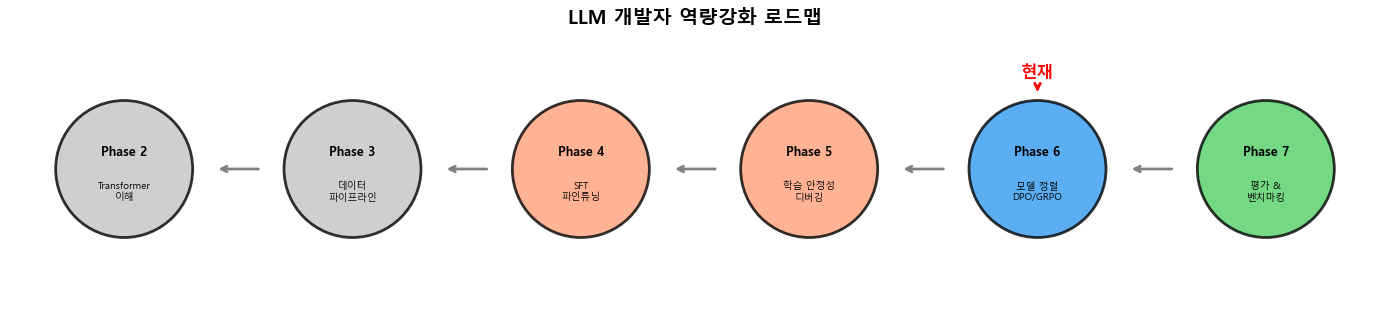

Phase 6 완료! 핵심 역량:
  ✓ SFT의 한계를 이해하고 DPO로 보완할 수 있다
  ✓ Preference 데이터를 준비하고 검증할 수 있다
  ✓ DPOTrainer로 실제 학습을 실행할 수 있다
  ✓ GRPO의 원리와 적합한 태스크를 알고 있다
  ✓ 상황에 맞는 정렬 기법을 선택할 수 있다


In [9]:
# === Phase 2-6 연결 시각화 ===

fig, ax = plt.subplots(figsize=(14, 6))

phases = [
    ('Phase 2', 'Transformer\n이해', '#c4c4c4'),
    ('Phase 3', '데이터\n파이프라인', '#c4c4c4'),
    ('Phase 4', 'SFT\n파인튜닝', '#ffa07a'),
    ('Phase 5', '학습 안정성\n디버깅', '#ffa07a'),
    ('Phase 6', '모델 정렬\nDPO/GRPO', '#339af0'),
    ('Phase 7', '평가 &\n벤치마킹', '#51cf66'),
]

for i, (phase, desc, color) in enumerate(phases):
    x = i * 2
    circle = plt.Circle((x, 0), 0.6, color=color, ec='black', linewidth=2, alpha=0.8)
    ax.add_patch(circle)
    ax.text(x, 0.15, phase, ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(x, -0.2, desc, ha='center', va='center', fontsize=7)
    
    if i < len(phases) - 1:
        ax.annotate('', xy=(x + 0.8, 0), xytext=(x + 1.2, 0),
                    arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

# 현재 위치 표시
ax.annotate('현재', xy=(8, 0.8), fontsize=12, fontweight='bold', color='red',
            ha='center')
ax.annotate('', xy=(8, 0.65), xytext=(8, 0.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))

ax.set_xlim(-1, 11)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('LLM 개발자 역량강화 로드맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Phase 6 완료! 핵심 역량:")
print("  ✓ SFT의 한계를 이해하고 DPO로 보완할 수 있다")
print("  ✓ Preference 데이터를 준비하고 검증할 수 있다")
print("  ✓ DPOTrainer로 실제 학습을 실행할 수 있다")
print("  ✓ GRPO의 원리와 적합한 태스크를 알고 있다")
print("  ✓ 상황에 맞는 정렬 기법을 선택할 수 있다")

---
## 8. Phase 6 체크포인트

| # | 질문 | 학습 위치 |
|---|------|----------|
| 1 | DPO의 손실 함수를 직관적으로 설명할 수 있는가? | 01 |
| 2 | Preference 데이터의 구조(chosen, rejected)를 이해하는가? | 02 |
| 3 | SFT 모델을 DPO로 추가 정렬해본 경험이 있는가? | 03 |
| 4 | GRPO의 원리와 DPO와의 차이를 설명할 수 있는가? | 04 |
| 5 | β(beta) 하이퍼파라미터의 역할을 아는가? | 01, 03 |

In [10]:
# === 핵심 원칙 ===

print("=" * 60)
print("Phase 6 핵심 원칙")
print("=" * 60)
print()
print('"정렬의 목적은 모델을 더 똑똑하게 만드는 것이 아니라,')
print(' 이미 아는 것을 더 잘 표현하게 만드는 것이다."')
print()
print('  지식은 SFT에서,')
print('  판단력은 DPO에서,')
print('  추론력은 GRPO에서 온다.')
print()
print("=" * 60)

Phase 6 핵심 원칙

"정렬의 목적은 모델을 더 똑똑하게 만드는 것이 아니라,
 이미 아는 것을 더 잘 표현하게 만드는 것이다."

  지식은 SFT에서,
  판단력은 DPO에서,
  추론력은 GRPO에서 온다.



---
## 정리

| 기법 | 보상 신호 | 필요 데이터 | 적합한 태스크 |
|------|----------|-----------|------------|
| **DPO** | Implicit | Preference 쌍 | 범용 정렬 |
| **GRPO** | 규칙 기반 | 문제 + 정답 | 수학/코드/추론 |

### 핵심 원칙

> **정렬의 목적은 "모델을 더 똑똑하게" 만드는 것이 아니라, "이미 아는 것을 더 잘 표현하게" 만드는 것이다.**  
> 지식은 SFT에서, 판단력은 DPO에서, 추론력은 GRPO에서 온다.